# Customer Churn Analysis BI

## Business Context

Customer churn is a major issue for subscription-based companies.  
The objective of this project is to analyze customer behavior, identify churn risk factors, and provide business recommendations to improve customer retention.

## Objectives

- Understand the overall churn rate
- Identify customer segments with high churn
- Analyze the impact of contract type, tenure, monthly charges, and payment method
- Build a clean dataset for dashboarding
- Provide actionable business recommendations

In [2]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Convert TotalCharges from object to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df = df.dropna(subset=["TotalCharges"])

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [10]:
# Create churn flag: Yes = 1, No = 0
df["Churn_Flag"] = df["Churn"].map({"Yes": 1, "No": 0})

In [11]:
# Create tenure groups
def tenure_group(tenure):
    if tenure <= 12:
        return "0-12 months"
    elif tenure <= 24:
        return "13-24 months"
    elif tenure <= 48:
        return "25-48 months"
    else:
        return "49+ months"

df["Tenure_Group"] = df["tenure"].apply(tenure_group)

In [12]:
# Create monthly charge groups
def monthly_charge_group(charge):
    if charge < 35:
        return "Low"
    elif charge < 70:
        return "Medium"
    else:
        return "High"

df["Monthly_Charge_Group"] = df["MonthlyCharges"].apply(monthly_charge_group)

In [13]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Risk_Level,Churn_Flag,Tenure_Group,Monthly_Charge_Group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,Medium Risk,0,0-12 months,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.5,No,Low Risk,0,25-48 months,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Medium Risk,1,0-12 months,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,Low Risk,0,25-48 months,Medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,High Risk,1,0-12 months,High


In [ ]:
df.shape

(7032, 24)

In [14]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
# Convert Churn into numeric flag for analysis
df["Churn_Flag"] = df["Churn"].map({"Yes": 1, "No": 0})

In [17]:
# Create customer tenure groups
def tenure_group(tenure):
    if tenure <= 12:
        return "0-12 months"
    elif tenure <= 24:
        return "13-24 months"
    elif tenure <= 48:
        return "25-48 months"
    else:
        return "49+ months"

df["Tenure_Group"] = df["tenure"].apply(tenure_group)

In [18]:
# Create monthly charge groups
def monthly_charge_group(charge):
    if charge < 35:
        return "Low"
    elif charge < 70:
        return "Medium"
    else:
        return "High"

df["Monthly_Charge_Group"] = df["MonthlyCharges"].apply(monthly_charge_group)

In [19]:
df[["Churn", "Churn_Flag", "tenure", "Tenure_Group", "MonthlyCharges", "Monthly_Charge_Group"]].head(10)

,Churn,Churn_Flag,tenure,Tenure_Group,MonthlyCharges,Monthly_Charge_Group
0,No,0,1,0-12 months,29.85,Low
1,No,0,34,25-48 months,56.95,Medium
2,Yes,1,2,0-12 months,53.85,Medium
3,No,0,45,25-48 months,42.30,Medium
4,Yes,1,2,0-12 months,70.70,High
5,Yes,1,8,0-12 months,99.65,High
6,No,0,22,13-24 months,89.10,High
7,No,0,10,0-12 months,29.75,Low
8,Yes,1,28,25-48 months,104.80,High
9,No,0,62,49+ months,56.15,Medium


In [ ]:
df.to_csv("customer_churn_cleaned.csv", index=False)

In [ ]:
from google.colab import files
files.download("customer_churn_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 1.1 Data Cleaning Summary

The dataset initially contained 7,043 rows and 21 columns.  
The `TotalCharges` column was converted from object to numeric format.  
After removing missing values in `TotalCharges`, the cleaned dataset contains 7,032 rows.  

Additional columns were created to support the analysis:
- `Churn_Flag`: numeric churn indicator
- `Tenure_Group`: customer tenure segmentation
- `Monthly_Charge_Group`: monthly charge segmentation

# 2. Business Churn Analysis

In this section, we analyze customer churn from a business perspective.  
The goal is to understand which customer profiles are more likely to leave and identify actionable insights for customer retention.

## 2.1 Overall Churn Rate

The overall churn rate gives a first view of customer retention performance.  
It helps measure the proportion of customers who left the company.

In [ ]:
total_customers = len(df)
churned_customers = df["Churn_Flag"].sum()
retained_customers = total_customers - churned_customers
churn_rate = df["Churn_Flag"].mean() * 100

print(f"Total customers: {total_customers}")
print(f"Churned customers: {churned_customers}")
print(f"Retained customers: {retained_customers}")
print(f"Churn rate: {churn_rate:.2f}%")

Total customers: 7032
Churned customers: 1869
Retained customers: 5163
Churn rate: 26.58%


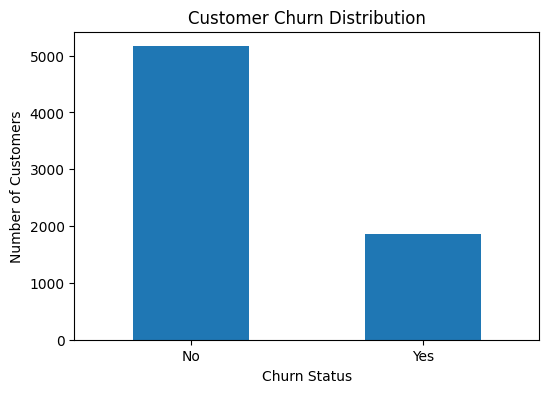

In [ ]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6,4))
churn_counts.plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

### Insight

The dataset shows the proportion of customers who churned versus those who stayed.  
This churn rate will be used as a baseline to compare churn across different customer segments.

## 2.2 Churn Rate by Contract Type

Contract type is an important factor because it reflects the level of customer commitment.  
Customers with short-term contracts may be more likely to leave than customers with long-term contracts.

In [ ]:
contract_churn = (
    df.groupby("Contract")
    .agg(
        total_customers=("customerID", "count"),
        churned_customers=("Churn_Flag", "sum"),
        churn_rate=("Churn_Flag", "mean")
    )
    .reset_index()
)

contract_churn["churn_rate"] = contract_churn["churn_rate"] * 100
contract_churn = contract_churn.sort_values(by="churn_rate", ascending=False)

contract_churn

,Contract,total_customers,churned_customers,churn_rate
0,Month-to-month,3875,1655,42.709677
1,One year,1472,166,11.277174
2,Two year,1685,48,2.848665


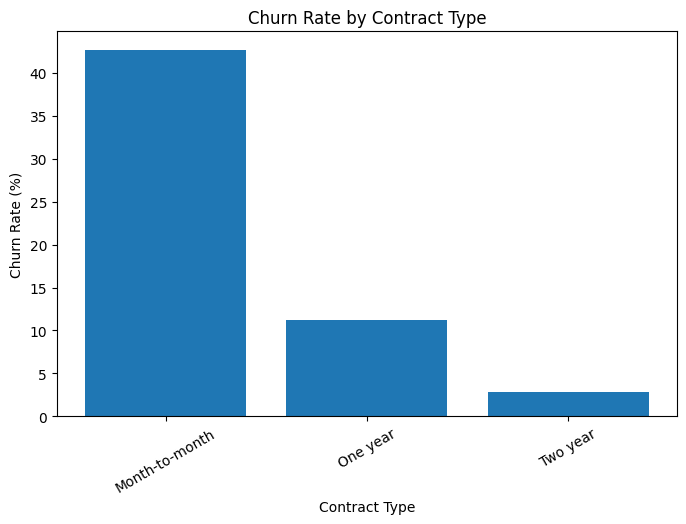

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(contract_churn["Contract"], contract_churn["churn_rate"])
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

### Insight

Customers with month-to-month contracts have a much higher churn rate than customers with one-year or two-year contracts.  
This suggests that long-term contracts can improve customer retention.

## 2.3 Churn Rate by Customer Tenure

Tenure represents how long a customer has been with the company.  
Analyzing churn by tenure helps identify whether new or long-term customers are more likely to leave.

In [ ]:
tenure_order = ["0-12 months", "13-24 months", "25-48 months", "49+ months"]

tenure_churn = (
    df.groupby("Tenure_Group")
    .agg(
        total_customers=("customerID", "count"),
        churned_customers=("Churn_Flag", "sum"),
        churn_rate=("Churn_Flag", "mean")
    )
    .reindex(tenure_order)
    .reset_index()
)

tenure_churn["churn_rate"] = tenure_churn["churn_rate"] * 100
tenure_churn

,Tenure_Group,total_customers,churned_customers,churn_rate
0,0-12 months,2175,1037,47.678161
1,13-24 months,1024,294,28.710938
2,25-48 months,1594,325,20.388959
3,49+ months,2239,213,9.513176


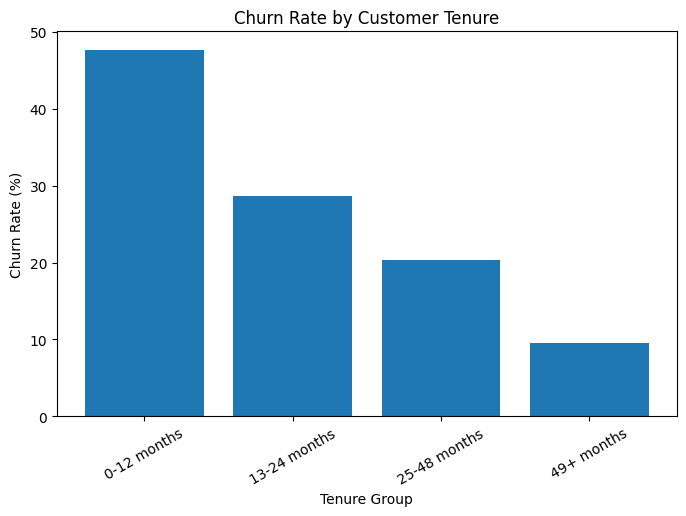

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(tenure_churn["Tenure_Group"], tenure_churn["churn_rate"])
plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

### Insight

Customers in the first 12 months show a higher churn rate.  
This indicates that the onboarding period is critical for improving retention.

## 2.4 Churn Rate by Monthly Charges

Monthly charges can influence churn because customers may leave if they feel the service cost is too high compared to the value received.

In [ ]:
charge_order = ["Low", "Medium", "High"]

charge_churn = (
    df.groupby("Monthly_Charge_Group")
    .agg(
        total_customers=("customerID", "count"),
        churned_customers=("Churn_Flag", "sum"),
        churn_rate=("Churn_Flag", "mean"),
        avg_monthly_charges=("MonthlyCharges", "mean")
    )
    .reindex(charge_order)
    .reset_index()
)

charge_churn["churn_rate"] = charge_churn["churn_rate"] * 100
charge_churn["avg_monthly_charges"] = charge_churn["avg_monthly_charges"].round(2)

charge_churn

,Monthly_Charge_Group,total_customers,churned_customers,churn_rate,avg_monthly_charges
0,Low,1725,188,10.898551,22.00
1,Medium,1718,407,23.690338,54.72
2,High,3589,1274,35.497353,90.19


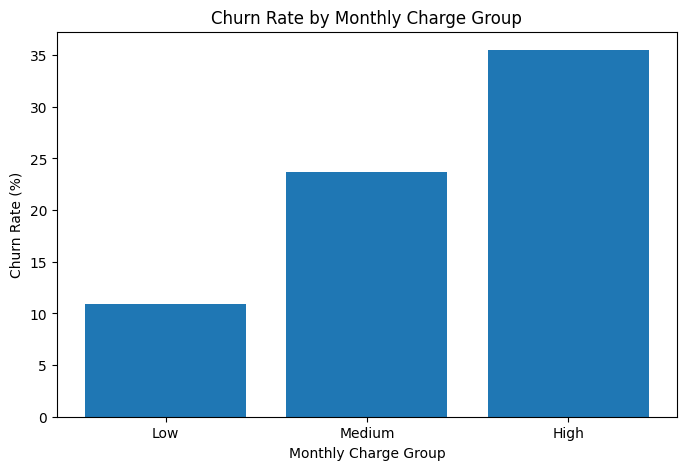

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(charge_churn["Monthly_Charge_Group"], charge_churn["churn_rate"])
plt.title("Churn Rate by Monthly Charge Group")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

### Insight

Customers with high monthly charges tend to have a higher churn rate.  
This may indicate price sensitivity or a mismatch between customer expectations and perceived service value.

## 2.5 Churn Rate by Payment Method

Payment method may reflect different customer behaviors and levels of engagement.  
Some payment methods can be associated with higher churn risk.

In [ ]:
payment_churn = (
    df.groupby("PaymentMethod")
    .agg(
        total_customers=("customerID", "count"),
        churned_customers=("Churn_Flag", "sum"),
        churn_rate=("Churn_Flag", "mean")
    )
    .reset_index()
)

payment_churn["churn_rate"] = payment_churn["churn_rate"] * 100
payment_churn = payment_churn.sort_values(by="churn_rate", ascending=False)

payment_churn

,PaymentMethod,total_customers,churned_customers,churn_rate
2,Electronic check,2365,1071,45.285412
3,Mailed check,1604,308,19.201995
0,Bank transfer (automatic),1542,258,16.731518
1,Credit card (automatic),1521,232,15.253123


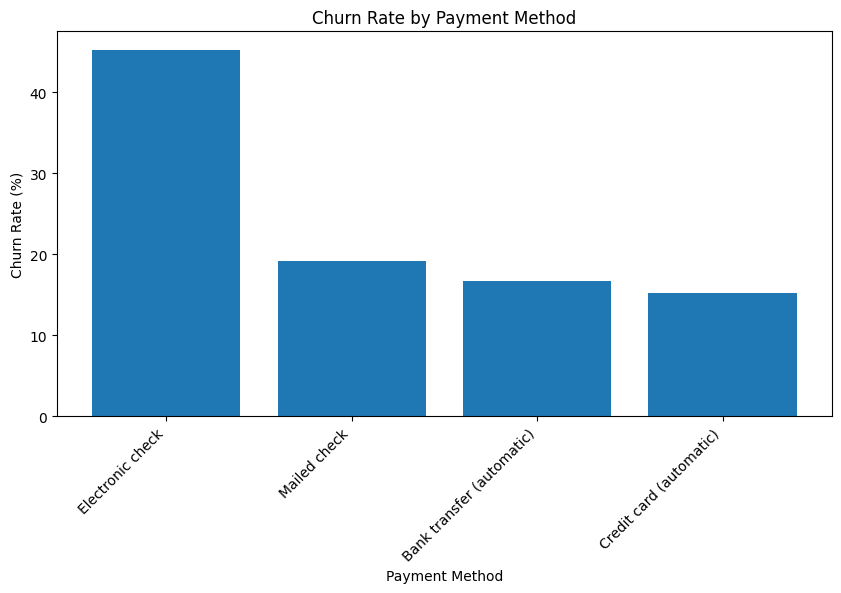

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(payment_churn["PaymentMethod"], payment_churn["churn_rate"])
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

### Insight

Customers using electronic check show a higher churn rate compared to other payment methods.  
This segment should be monitored more closely in retention strategies.

## 2.6 Churn Rate by Internet Service

Internet service type can influence customer satisfaction and churn behavior.  
This analysis helps identify whether some service categories are more exposed to churn.

In [ ]:
internet_churn = (
    df.groupby("InternetService")
    .agg(
        total_customers=("customerID", "count"),
        churned_customers=("Churn_Flag", "sum"),
        churn_rate=("Churn_Flag", "mean")
    )
    .reset_index()
)

internet_churn["churn_rate"] = internet_churn["churn_rate"] * 100
internet_churn = internet_churn.sort_values(by="churn_rate", ascending=False)

internet_churn

,InternetService,total_customers,churned_customers,churn_rate
1,Fiber optic,3096,1297,41.892765
0,DSL,2416,459,18.998344
2,No,1520,113,7.434211


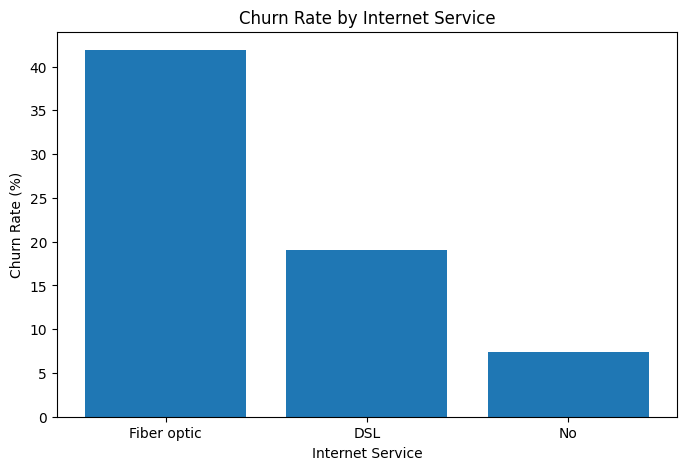

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(internet_churn["InternetService"], internet_churn["churn_rate"])
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

### Insight

Customers using fiber optic service may show a higher churn rate.  
This could indicate expectations related to service quality, pricing, or customer experience.

## 2.7 Key Business Insights

Based on the churn analysis, several important patterns can be identified:

1. Customers with high monthly charges have the highest churn rate, around 35%.  
   This suggests that price sensitivity may be an important churn driver.

2. Customers using electronic check have the highest churn rate, above 40%.  
   This payment method should be monitored more closely because it is strongly associated with customer churn.

3. Fiber optic customers show the highest churn rate among internet service categories, around 42%.  
   This may indicate issues related to pricing, service expectations, or customer experience.

4. Month-to-month contracts have a much higher churn rate than one-year and two-year contracts.  
   This shows that customer commitment is a key factor in retention.

5. Customers in their first 12 months have the highest churn rate.  
   This means the onboarding period is critical for reducing churn.

## 2.8 Business Interpretation

The churn analysis shows that churn is not random.  
Customers are more likely to leave when they have short-term contracts, high monthly charges, low tenure, electronic check payment method, or fiber optic internet service.

From a business perspective, this means the company should focus retention efforts on customers who combine several risk factors.  
For example, a customer with a month-to-month contract, high monthly charges, and short tenure should be considered a priority target for retention campaigns.

# 3. Customer Risk Segmentation

In this section, we create a simple rule-based segmentation to classify customers into different churn risk levels.  
This helps business teams prioritize retention actions.

In [7]:
# Create a rule-based churn risk segmentation
def churn_risk(row):
    if (
        row["Contract"] == "Month-to-month"
        and row["tenure"] <= 12
        and row["MonthlyCharges"] >= 70
    ):
        return "High Risk"
    elif (
        row["Contract"] == "Month-to-month"
        or row["tenure"] <= 24
        or row["MonthlyCharges"] >= 70
    ):
        return "Medium Risk"
    else:
        return "Low Risk"

df["Churn_Risk_Level"] = df.apply(churn_risk, axis=1)

In [8]:
df[["customerID", "Contract", "tenure", "MonthlyCharges", "Churn", "Churn_Risk_Level"]].head(10)

,customerID,Contract,tenure,MonthlyCharges,Churn,Churn_Risk_Level
0,7590-VHVEG,Month-to-month,1,29.85,No,Medium Risk
1,5575-GNVDE,One year,34,56.95,No,Low Risk
2,3668-QPYBK,Month-to-month,2,53.85,Yes,Medium Risk
3,7795-CFOCW,One year,45,42.30,No,Low Risk
4,9237-HQITU,Month-to-month,2,70.70,Yes,High Risk
5,9305-CDSKC,Month-to-month,8,99.65,Yes,High Risk
6,1452-KIOVK,Month-to-month,22,89.10,No,Medium Risk
7,6713-OKOMC,Month-to-month,10,29.75,No,Medium Risk
8,7892-POOKP,Month-to-month,28,104.80,Yes,Medium Risk
9,6388-TABGU,One year,62,56.15,No,Low Risk


In [20]:
risk_summary = (
    df.groupby("Churn_Risk_Level")
    .agg(
        total_customers=("customerID", "count"),
        churned_customers=("Churn_Flag", "sum"),
        churn_rate=("Churn_Flag", "mean"),
        avg_monthly_charges=("MonthlyCharges", "mean"),
        avg_tenure=("tenure", "mean")
    )
    .reset_index()
)

risk_summary["churn_rate"] = risk_summary["churn_rate"] * 100
risk_summary["churn_rate"] = risk_summary["churn_rate"].round(2)
risk_summary["avg_monthly_charges"] = risk_summary["avg_monthly_charges"].round(2)
risk_summary["avg_tenure"] = risk_summary["avg_tenure"].round(1)

risk_summary = risk_summary.sort_values(by="churn_rate", ascending=False)

risk_summary

,Churn_Risk_Level,total_customers,churned_customers,churn_rate,avg_monthly_charges,avg_tenure
0,High Risk,860,595,69.19,83.02,5.0
2,Medium Risk,4913,1241,25.26,68.86,31.8
1,Low Risk,1270,33,2.60,36.55,52.9


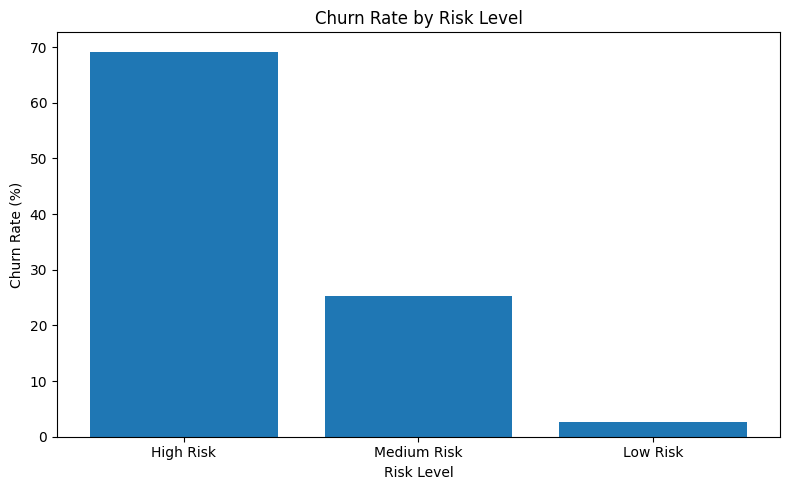

In [21]:
plt.figure(figsize=(8,5))
plt.bar(risk_summary["Churn_Risk_Level"], risk_summary["churn_rate"])
plt.title("Churn Rate by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight

The rule-based risk segmentation helps identify customers who are more likely to churn.  
High-risk customers should be prioritized for retention campaigns, personalized offers, and proactive customer support.

In [22]:
df.to_csv("customer_churn_final.csv", index=False)
risk_summary.to_csv("risk_summary.csv", index=False)

In [23]:
from google.colab import files

files.download("customer_churn_final.csv")
files.download("risk_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Insight

The risk segmentation shows a clear difference between customer groups.  
High-risk customers have a much higher churn rate, close to 70%, while low-risk customers have a very low churn rate.

This confirms that customers with month-to-month contracts, short tenure, and high monthly charges are the most vulnerable to churn.  
From a business perspective, this segmentation can help the company prioritize retention actions and focus on customers who need immediate attention.

# 4. Business Recommendations

Based on the churn analysis and risk segmentation, the following recommendations can help improve customer retention:

1. Prioritize high-risk customers  
   Customers classified as high risk should be contacted first by the customer success or sales team.

2. Improve onboarding during the first 12 months  
   Since new customers are more likely to churn, the company should strengthen onboarding, follow-up emails, tutorials, and customer support.

3. Encourage longer-term contracts  
   Month-to-month customers should receive incentives to switch to one-year or two-year contracts, such as discounts or loyalty benefits.

4. Monitor high monthly charge customers  
   Customers with high monthly charges may be more price-sensitive. Personalized offers or service reviews could help reduce churn.

5. Investigate fiber optic customer experience  
   Since fiber optic customers show a high churn rate, the company should analyze whether the issue is related to price, service quality, or customer expectations.

6. Review electronic check payment users  
   Customers using electronic check have a high churn rate. The company could encourage automatic payment methods or provide additional support for this segment.

In [24]:
df.to_csv("customer_churn_final.csv", index=False)
risk_summary.to_csv("risk_summary.csv", index=False)

In [25]:
from google.colab import files

files.download("customer_churn_final.csv")
files.download("risk_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>